# Coleta de Bases Econométricas — Brasil e Internacionais

Pipeline automatizado para coleta, consolidação e exportação de 36 séries macroeconômicas mensais (2017–2025).

**Fontes:** BCB/SGS · IBGE/SIDRA · FRED · Yahoo Finance

In [16]:
%pip install pandas yfinance fredapi python-dateutil matplotlib seaborn openpyxl packaging statsmodels -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports e Configuração Global

In [17]:
import os, json, warnings
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import yfinance as yf
from dateutil.relativedelta import relativedelta
from fredapi import Fred
from packaging import version

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Frequência mensal compatível com a versão do Pandas ──
MONTH_FREQ = "ME" if version.parse(pd.__version__) >= version.parse("2.2.0") else "M"

# ── Período de análise ──
START_DATE = "2017-01-01"
END_DATE   = "2025-12-31"

# ── FRED API Key ──
FRED_API_KEY = os.getenv("FRED_API_KEY", "e7f4eed40425765c738c91efa96bc5ff")

# ── Séries a coletar ──
DATA_CONFIG = {
    # ═══════════════════════════════════════════════════════════════
    # BLOCO 1 — Indicadores estruturais Brasil (original)
    # ═══════════════════════════════════════════════════════════════
    # "IPCA":          {"source": "sidra", "table": 1737,  "variable": 63,   "name": "IPCA_mensal"},  # Comentado por solicitação
    "IBC_Br":        {"source": "bcb",   "series": 24363,                  "name": "IBC_Br"},
    "Selic":         {"source": "bcb",   "series": 4189,  "resample": True,"name": "Selic"},
    "Cambio":        {"source": "bcb",   "series": 1,     "resample": True,"name": "Cambio_USDBRL"},
    "Desemprego":    {"source": "sidra", "table": 6381,  "variable": 4099, "name": "Desemprego"},

    # Commodities internacionais
    "Brent":         {"source": "fred",  "series": "DCOILBRENTEU", "resample": True, "name": "Brent_USD"},
    "Soja":          {"source": "fred",  "series": "PSOYBUSDM",                      "name": "Soja_USD"},
    "Minerio":       {"source": "fred",  "series": "PIORECRUSDM",                    "name": "Minerio_USD"},

    # Mercado financeiro
    "Ibovespa":      {"source": "yahoo", "ticker": "^BVSP",                "name": "Ibovespa"},

    # FGV – Confiança
    "ICC_FGV":       {"source": "bcb",   "series": 4393,                   "name": "ICC_FGV"},

    # BCB – Crédito
    "Credito_Total": {"source": "bcb",   "series": 20542,                  "name": "Credito_Total"},
    "Inadimplencia": {"source": "bcb",   "series": 21085,                  "name": "Inadimplencia"},

    # IBGE – Atividade setorial
    "Massa_Salarial":{"source": "sidra", "table": 6392,  "variable": 6293, "name": "Massa_Salarial"},

    # Internacional – EUA
    "CPI_USA":       {"source": "fred",  "series": "CPIAUCSL",             "name": "CPI_USA"},
    #"PPI_USA":       {"source": "fred",  "series": "PPIACO",               "name": "PPI_USA"},
    "Prod_Ind_USA":  {"source": "fred",  "series": "INDPRO",               "name": "Prod_Ind_USA"},

    # ═══════════════════════════════════════════════════════════════
    # BLOCO 2 — Yahoo Finance (commodities e mercados)
    # ═══════════════════════════════════════════════════════════════
    "Cafe":          {"source": "yahoo", "ticker": "KC=F",                 "name": "Cafe_USD"},
    "Ouro":          {"source": "yahoo", "ticker": "GC=F",                 "name": "Ouro_USD"},
    "GasNatural":    {"source": "yahoo", "ticker": "NG=F",                 "name": "GasNatural_USD"},
    "Cobre":         {"source": "yahoo", "ticker": "HG=F",                 "name": "Cobre_USD"},
    "ETF_Emerg":     {"source": "yahoo", "ticker": "EEM",                  "name": "ETF_Emergentes"},

    # ═══════════════════════════════════════════════════════════════
    # BLOCO 3 — BCB/SGS (preços e crédito)
    # ═══════════════════════════════════════════════════════════════
    #"IGP_DI":        {"source": "bcb",   "series": 190,                    "name": "IGP_DI"},
    "INCC":          {"source": "bcb",   "series": 192,                    "name": "INCC"},
    #"IPA_DI":        {"source": "bcb",   "series": 7450,                   "name": "IPA_DI"},       # Removido — r=0.9961 com IGPM (IPA compõe 60% do IGP-M)
    #"Credito_PJ":    {"source": "bcb",   "series": 20631,                  "name": "Credito_PJ"},   # Removido — subcomponente de Credito_Total (r=0.97)
    #"Credito_PF":    {"source": "bcb",   "series": 20632,                  "name": "Credito_PF"},   # Removido — subcomponente de Credito_Total (r=0.94)
    "ICE_Empres":    {"source": "bcb",   "series": 21859,                  "name": "ICE_Empresarial"},

    # ═══════════════════════════════════════════════════════════════
    # BLOCO 4 — FRED (EUA)
    # ═══════════════════════════════════════════════════════════════
    "Housing":       {"source": "fred",  "series": "HOUST",                "name": "Housing_Starts_EUA"},
    #"PCE":           {"source": "fred",  "series": "PCEPI",                "name": "PCE_Deflator"},  # Removido — r=0.9998 com CPI_USA (mesmo conceito: inflação ao consumidor EUA)
    "DollarIdx":     {"source": "fred",  "series": "DTWEXBGS", "resample": True, "name": "Dollar_Index_Fed"},

    # ═══════════════════════════════════════════════════════════════
    # BLOCO 5 — IBGE/SIDRA (atividade setorial)
    # ═══════════════════════════════════════════════════════════════
    "PMS_Volume":    {"source": "sidra", "table": 5906,  "variable": 7167,
                      "classification": "c11046/56726",                     "name": "PMS_Volume"},
    #"PMC_Ampliado":  {"source": "sidra", "table": 8186,  "variable": 11709,
    #                  "classification": "c11046/56736",                     "name": "PMC_Ampliado"},

    # ═══════════════════════════════════════════════════════════════
    # BLOCO 6 — Séries complementares Brasil (BCB/SGS)
    # ═══════════════════════════════════════════════════════════════
    #"IGPM":          {"source": "bcb",   "series": 189,                    "name": "IGPM"},
    #"INPC":          {"source": "bcb",   "series": 188,                    "name": "INPC"},
    "M2":            {"source": "bcb",   "series": 27815,                  "name": "M2"},
    "Divida_PIB":    {"source": "bcb",   "series": 4513,                   "name": "Divida_PIB"},
    "Vendas_Varejo": {"source": "bcb",   "series": 1455,                   "name": "Vendas_Varejo"},
    #"Receita_Servicos":{"source": "bcb", "series": 21637,                  "name": "Receita_Servicos"},  # Removido — r=0.96 com PMS_Volume (mesmo setor, mesmo padrão)
    #"Balanca_Comercial":{"source":"bcb", "series": 22707,                  "name": "Balanca_Comercial"},
    "NUCI_FGV":      {"source": "bcb",   "series": 24352,                  "name": "NUCI_FGV"},
    # "ICEI":        {"source": "bcb",   "series": 4393,                   "name": "ICEI"},  # Removido — duplicata de ICC_FGV (mesmo BCB 4393)
    #"IHH_Horas_Trab":{"source": "bcb",   "series": 4380,                   "name": "IHH_Horas_Trab"},  # Removido — |r|≥0.90 com 6+ séries (comportamento indistinguível)
    #"EAI_Emprego_Ind":{"source":"bcb",   "series": 4381,                   "name": "EAI_Emprego_Ind"},

    # ═══════════════════════════════════════════════════════════════
    # BLOCO 7 — Mercado internacional + IBGE PIM
    # ═══════════════════════════════════════════════════════════════
    "SP500":         {"source": "yahoo", "ticker": "^GSPC",                "name": "SP500"},
#    "Fed_Funds_Rate":{"source": "fred",  "series": "FEDFUNDS",             "name": "Fed_Funds_Rate"}, # MAPE muito elevado
#    "PIM":           {"source": "sidra", "table": 8888,  "variable": 11602,
#                      "classification": "c544/129314",                      "name": "PIM"}, # Removido — instabilidade de base
}

print(f"✓ Pandas {pd.__version__} | freq mensal = '{MONTH_FREQ}'")
print(f"  Período: {START_DATE} → {END_DATE} | {len(DATA_CONFIG)} variáveis")

✓ Pandas 2.1.4 | freq mensal = 'M'
  Período: 2017-01-01 → 2025-12-31 | 29 variáveis


## 3. Funções de Coleta de Dados

In [18]:
def _normalize_monthly_index(s: pd.Series) -> pd.Series:
    """Padroniza qualquer índice temporal para mês-início (ex.: 2024-01-01)."""
    s = s.copy()
    s.index = s.index.to_period("M").to_timestamp()
    s = s[~s.index.duplicated(keep="first")]
    return s


def fetch_bcb_series(series_id: int, start: str, end: str) -> pd.Series:
    """
    Coleta série do BCB/SGS. Divide em chunks de 10 anos (limite da API
    para séries diárias). start/end no formato dd/mm/aaaa.
    """
    start_dt = datetime.strptime(start, "%d/%m/%Y")
    end_dt   = datetime.strptime(end,   "%d/%m/%Y")
    all_data: list[dict] = []

    current = start_dt
    while current < end_dt:
        chunk_end = min(current + relativedelta(years=10), end_dt)
        url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_id}/dados"
        params = {
            "formato": "json",
            "dataInicial": current.strftime("%d/%m/%Y"),
            "dataFinal":   chunk_end.strftime("%d/%m/%Y"),
        }
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        if data:
            all_data.extend(data)
        current = chunk_end + relativedelta(days=1)

    if not all_data:
        return pd.Series(dtype=float, name=f"BCB_{series_id}")

    df = pd.DataFrame(all_data)
    df["data"]  = pd.to_datetime(df["data"], format="%d/%m/%Y")
    df["valor"] = df["valor"].str.replace(",", ".").astype(float)
    df = df.set_index("data").sort_index()
    df = df[~df.index.duplicated(keep="first")]
    return df["valor"]


def fetch_sidra_series(table_id: int, variable: int, classification: str = None) -> pd.Series:
    """Coleta série do IBGE/SIDRA. Aceita classificação opcional (ex.: 'c11046/56726')."""
    url = f"https://apisidra.ibge.gov.br/values/t/{table_id}/n1/all/v/{variable}/p/all"
    if classification:
        url += f"/{classification}"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json()

    if len(data) <= 1:
        return pd.Series(dtype=float, name=f"SIDRA_{table_id}")

    df = pd.DataFrame(data[1:], columns=data[0])

    def _parse_period(p: str) -> datetime | None:
        p = str(p).strip()
        try:
            if len(p) == 6:
                return datetime.strptime(p, "%Y%m")
            if len(p) == 5 and p[4:].isdigit() and int(p[4:]) <= 4:
                return datetime(int(p[:4]), int(p[4:]) * 3, 1)
        except ValueError:
            pass
        return pd.NaT

    period_col = "D3C" if "D3C" in df.columns else "D2N"
    df["date"]  = df[period_col].apply(_parse_period)
    df["value"] = pd.to_numeric(df["V"], errors="coerce")
    df = df[~df["V"].isin(["...", ".."])]
    df = df.dropna(subset=["date", "value"]).set_index("date").sort_index()
    return df["value"]


def fetch_fred_series(series_id: str, start: str, end: str) -> pd.Series:
    """Coleta série do FRED (Federal Reserve Economic Data)."""
    fred = Fred(api_key=FRED_API_KEY)
    s = fred.get_series(series_id, observation_start=start, observation_end=end)
    s.name = series_id
    return s.dropna()


def fetch_yahoo_series(ticker: str, start: str, end: str) -> pd.Series:
    """Coleta preço de fechamento do Yahoo Finance e agrega mensalmente."""
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        return pd.Series(dtype=float, name=ticker)

    if isinstance(df.columns, pd.MultiIndex):
        col = "Close" if "Close" in df.columns.get_level_values(0) else "Adj Close"
        close = df[col].iloc[:, 0]
    else:
        close = df.get("Close", df.get("Adj Close"))
        if close is None:
            return pd.Series(dtype=float, name=ticker)

    return close.resample(MONTH_FREQ).last()


def collect_all_data() -> dict[str, pd.Series]:
    """Coleta todas as séries definidas em DATA_CONFIG e normaliza para índice mensal."""
    start_bcb = datetime.strptime(START_DATE, "%Y-%m-%d").strftime("%d/%m/%Y")
    end_bcb   = datetime.strptime(END_DATE,   "%Y-%m-%d").strftime("%d/%m/%Y")
    results: dict[str, pd.Series] = {}

    print("📊 Iniciando coleta de dados…\n")

    for i, (key, cfg) in enumerate(DATA_CONFIG.items(), 1):
        print(f"  [{i:2d}/{len(DATA_CONFIG)}] {key:20s}", end=" ")
        try:
            src = cfg["source"]

            if src == "bcb":
                s = fetch_bcb_series(cfg["series"], start_bcb, end_bcb)
                if cfg.get("resample"):
                    s = s.resample(MONTH_FREQ).last()

            elif src == "sidra":
                s = fetch_sidra_series(cfg["table"], cfg["variable"],
                                       cfg.get("classification"))

            elif src == "fred":
                s = fetch_fred_series(cfg["series"], START_DATE, END_DATE)
                if cfg.get("resample"):
                    s = s.resample(MONTH_FREQ).last()

            elif src == "yahoo":
                s = fetch_yahoo_series(cfg["ticker"], START_DATE, END_DATE)

            else:
                raise ValueError(f"Fonte desconhecida: {src}")

            # ── Normalizar TODOS os índices para mês-início ──
            s = _normalize_monthly_index(s)
            s.name = cfg["name"]
            results[cfg["name"]] = s
            print(f"✓ {len(s):>4d} registros")

        except Exception as e:
            print(f"✗ {str(e)[:60]}")
            results[cfg["name"]] = pd.Series(dtype=float, name=cfg["name"])

    print(f"\n✅ Coleta concluída — {sum(len(v) for v in results.values())} registros totais")
    return results

print("✓ Funções de coleta carregadas")

✓ Funções de coleta carregadas


## 4. Coleta dos Dados

In [19]:
# Coletar e consolidar
data_dict = collect_all_data()

df = pd.DataFrame(data_dict).sort_index()
df = df[(df.index >= pd.Timestamp(START_DATE)) & (df.index <= pd.Timestamp(END_DATE))].dropna(how="all")

# Forward fill para preencher gaps pontuais (ex.: CPI_USA out/2025)
n_nan_before = df.isna().sum().sum()
df = df.ffill()
n_filled = n_nan_before - df.isna().sum().sum()
if n_filled:
    print(f"⚠️ Forward fill: {n_filled} valor(es) preenchido(s)")

print(f"\n📋 Base: {len(df)} meses × {len(df.columns)} variáveis "
      f"({df.index.min():%Y-%m} a {df.index.max():%Y-%m})")
print(f"\n{'Variável':22s} {'Cobertura':>10s}  {'Obs':>5s}")
print("─" * 42)
for col in df.columns:
    n = df[col].notna().sum()
    pct = n / len(df) * 100
    flag = "✓" if pct >= 95 else "⚠" if pct >= 50 else "✗"
    print(f"  {flag} {col:20s} {pct:6.1f}%   {n:>4d}/{len(df)}")

📊 Iniciando coleta de dados…

  [ 1/29] IBC_Br               

✓  108 registros
  [ 2/29] Selic                ✓  108 registros
  [ 3/29] Cambio               ✓  108 registros
  [ 4/29] Desemprego           ✓  168 registros
  [ 5/29] Brent                ✓  108 registros
  [ 6/29] Soja                 ✓  108 registros
  [ 7/29] Minerio              ✓  108 registros
  [ 8/29] Ibovespa             ✓  108 registros
  [ 9/29] ICC_FGV              ✓  108 registros
  [10/29] Credito_Total        ✓  108 registros
  [11/29] Inadimplencia        ✓  108 registros
  [12/29] Massa_Salarial       ✓  168 registros
  [13/29] CPI_USA              ✓  107 registros
  [14/29] Prod_Ind_USA         ✓  108 registros
  [15/29] Cafe                 ✓  108 registros
  [16/29] Ouro                 ✓  108 registros
  [17/29] GasNatural           ✓  108 registros
  [18/29] Cobre                ✓  108 registros
  [19/29] ETF_Emerg            ✓  108 registros
  [20/29] INCC                 ✓  108 registros
  [21/29] ICE_Empres           ✓  108 registros
  [22/29] Housing      

## 5. Análise Exploratória

In [20]:
# Tabela de estatísticas descritivas completa
stats = pd.DataFrame({
    "Obs":      df.count(),
    "Média":    df.mean(),
    "Desv.Pad": df.std(),
    "Mín":      df.min(),
    "Mediana":  df.median(),
    "Máx":      df.max(),
    "CV (%)":   (df.std() / df.mean() * 100),
    "Assimetria": df.skew(),
    "Curtose":  df.kurtosis(),
}).round(4)

stats.index.name = "Variável"
display(stats)

,Obs,Média,Desv.Pad,Mín,Mediana,Máx,CV (%),Assimetria,Curtose
Variável,,,,,,,,,
IBC_Br,108,99.54,6.16,83.57,98.72,114.20,6.19,0.30,-0.06
Selic,108,8.94,4.12,1.90,9.58,14.90,46.01,-0.19,-1.28
Cambio_USDBRL,108,4.74,0.88,3.10,5.09,6.19,18.52,-0.58,-1.04
Desemprego,108,10.52,2.92,5.10,11.70,14.90,27.76,-0.31,-1.29
Brent_USD,108,70.58,18.27,14.85,71.42,125.53,25.89,-0.00,1.35
Soja_USD,108,417.71,90.40,305.31,380.23,621.20,21.64,0.67,-0.83
Minerio_USD,108,106.33,31.18,57.86,104.25,215.82,29.33,1.18,2.20
Ibovespa,108,106453.10,22239.83,62711.00,108611.50,161125.00,20.89,-0.11,-0.41
ICC_FGV,108,115.41,9.94,96.82,113.20,139.39,8.61,0.38,-0.82


In [21]:
# Primeiras e últimas observações
display(df.head(5))
display(df.tail(5))

Variável,IBC_Br,Selic,Cambio_USDBRL,Desemprego,Brent_USD,Soja_USD,Minerio_USD,Ibovespa,ICC_FGV,Credito_Total,Inadimplencia,Massa_Salarial,CPI_USA,Prod_Ind_USA,Cafe_USD,Ouro_USD,GasNatural_USD,Cobre_USD,ETF_Emergentes,INCC,ICE_Empresarial,Housing_Starts_EUA,Dollar_Index_Fed,PMS_Volume,M2,Divida_PIB,Vendas_Varejo,NUCI_FGV,SP500
2017-01-01,90.02,13.17,3.13,12.70,55.25,379.59,80.82,64671.00,102.25,1537976.00,5.67,275679.00,243.62,98.76,149.55,1208.60,3.12,2.72,30.49,0.41,90.80,1190.00,116.22,86.70,5842419766.00,46.46,89.14,73.20,2278.87
2017-02-01,90.36,12.82,3.10,13.30,53.36,380.87,88.95,66662.00,113.80,1535492.00,5.57,274876.00,244.01,98.36,140.70,1252.60,2.77,2.70,31.02,0.65,88.40,1271.00,116.00,82.92,5861693498.00,47.26,82.01,73.70,2363.64
2017-03-01,99.05,12.15,3.17,13.90,52.20,366.10,87.20,64984.00,109.38,1540450.00,5.71,275110.00,243.89,99.01,139.30,1247.30,3.19,2.65,32.17,0.16,99.60,1190.00,114.79,89.89,5936525988.00,47.53,88.52,73.30,2362.72
2017-04-01,93.20,11.59,3.20,13.70,49.46,347.86,70.40,65403.00,109.01,1530470.00,5.73,274803.00,244.19,100.02,131.05,1266.10,3.28,2.60,32.71,-0.02,92.40,1146.00,114.79,85.94,5925396119.00,47.48,88.31,73.40,2384.20
2017-05-01,94.63,11.15,3.24,13.40,49.40,350.18,61.63,62711.00,103.49,1526937.00,5.93,275775.00,244.00,100.14,129.35,1272.00,3.07,2.58,33.64,0.63,105.00,1157.00,113.30,89.81,5947255664.00,48.01,90.43,74.00,2411.80


Variável,IBC_Br,Selic,Cambio_USDBRL,Desemprego,Brent_USD,Soja_USD,Minerio_USD,Ibovespa,ICC_FGV,Credito_Total,Inadimplencia,Massa_Salarial,CPI_USA,Prod_Ind_USA,Cafe_USD,Ouro_USD,GasNatural_USD,Cobre_USD,ETF_Emergentes,INCC,ICE_Empresarial,Housing_Starts_EUA,Dollar_Index_Fed,PMS_Volume,M2,Divida_PIB,Vendas_Varejo,NUCI_FGV,SP500
2025-08-01,110.50,14.90,5.43,5.60,67.83,372.96,103.29,141422.00,111.88,3894986.00,5.38,357941.00,323.29,101.62,396.85,3473.70,3.00,4.52,49.16,0.52,113.00,1291.00,120.21,110.62,14234319346.00,64.05,107.20,83.10,6460.26
2025-09-01,109.54,14.90,5.32,5.60,68.52,368.57,106.41,146237.00,110.20,3932501.00,5.30,359208.00,324.25,101.67,374.85,3840.80,3.30,4.80,52.65,0.17,111.90,1328.00,120.14,112.16,14459548295.00,64.57,102.68,83.80,6688.46
2025-10-01,110.17,14.90,5.38,5.40,65.44,371.57,106.87,149540.00,113.63,3965015.00,5.33,361398.00,324.25,101.22,392.05,3982.20,4.12,5.07,54.52,0.30,113.10,1272.00,121.39,112.95,14602895807.00,64.69,108.71,83.90,6840.20
2025-11-01,106.60,14.90,5.33,5.20,64.07,410.17,106.23,159072.00,118.65,4011475.00,5.33,367005.00,325.06,101.08,413.00,4218.30,4.85,5.19,53.55,0.27,103.20,1324.00,121.05,111.30,14624391758.00,65.17,116.05,81.70,6849.09
2025-12-01,107.36,14.90,5.50,5.10,61.35,391.55,107.59,161125.00,124.46,4096650.00,5.35,370172.00,326.03,101.61,350.20,4370.10,3.97,5.73,54.88,0.21,93.90,1387.00,119.75,119.52,14814169473.00,65.24,129.65,80.50,6896.24


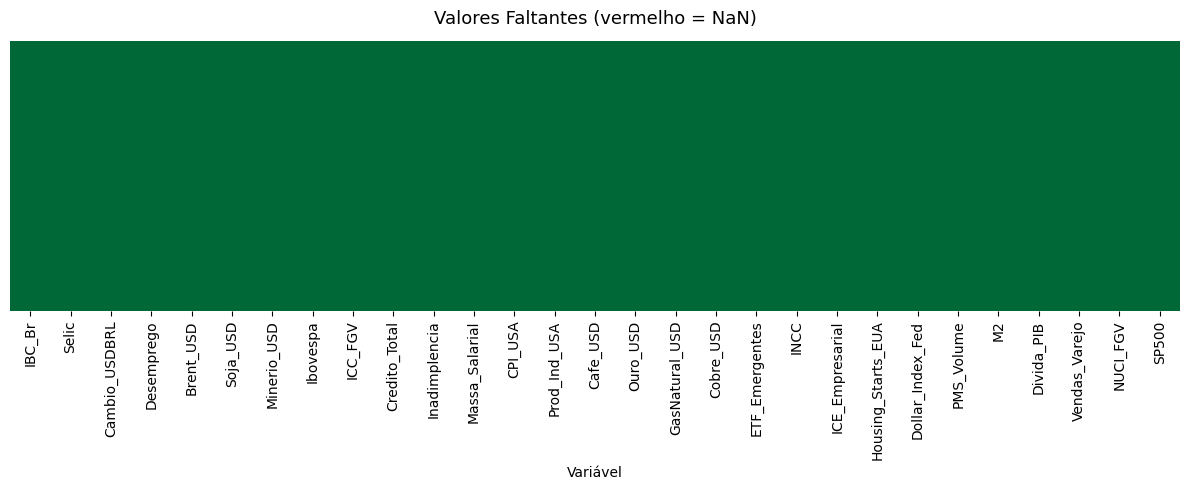

In [22]:
# Mapa de valores faltantes
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="RdYlGn_r", ax=ax)
ax.set_title("Valores Faltantes (vermelho = NaN)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

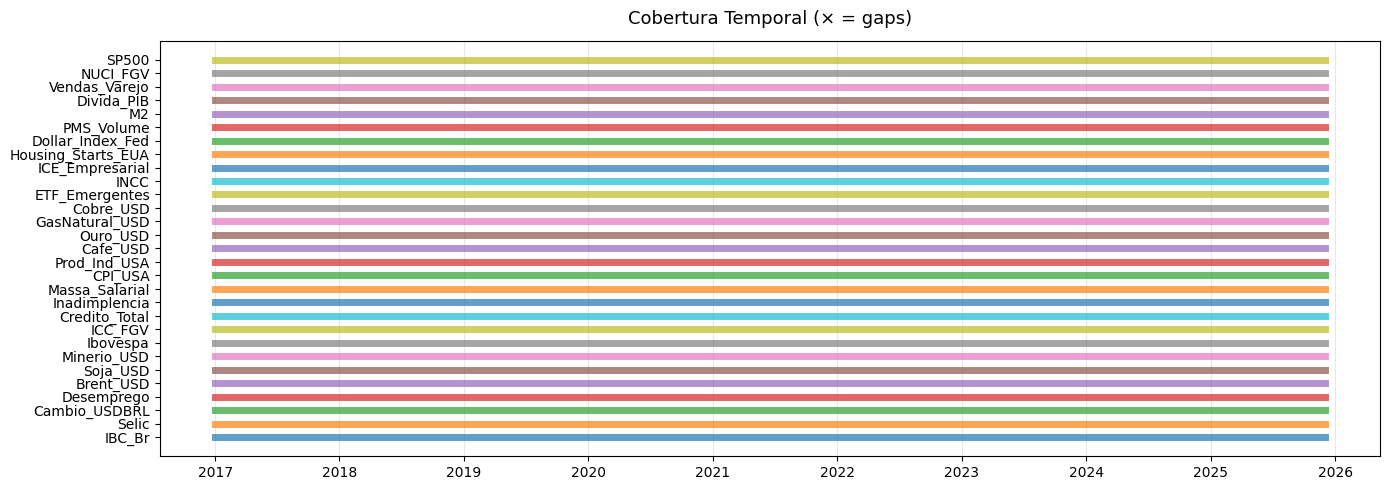

In [23]:
# Cobertura temporal por série
fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(df.columns):
    valid = df[col].dropna().index
    if len(valid):
        ax.plot([valid.min(), valid.max()], [i, i], lw=5, alpha=0.7, label=col)
        gaps = df.index[df[col].isna()]
        if len(gaps):
            ax.scatter(gaps, [i] * len(gaps), s=12, c="red", alpha=0.4, marker="x")

ax.set_yticks(range(len(df.columns)))
ax.set_yticklabels(df.columns)
ax.set_title("Cobertura Temporal (× = gaps)", fontsize=13, pad=12)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

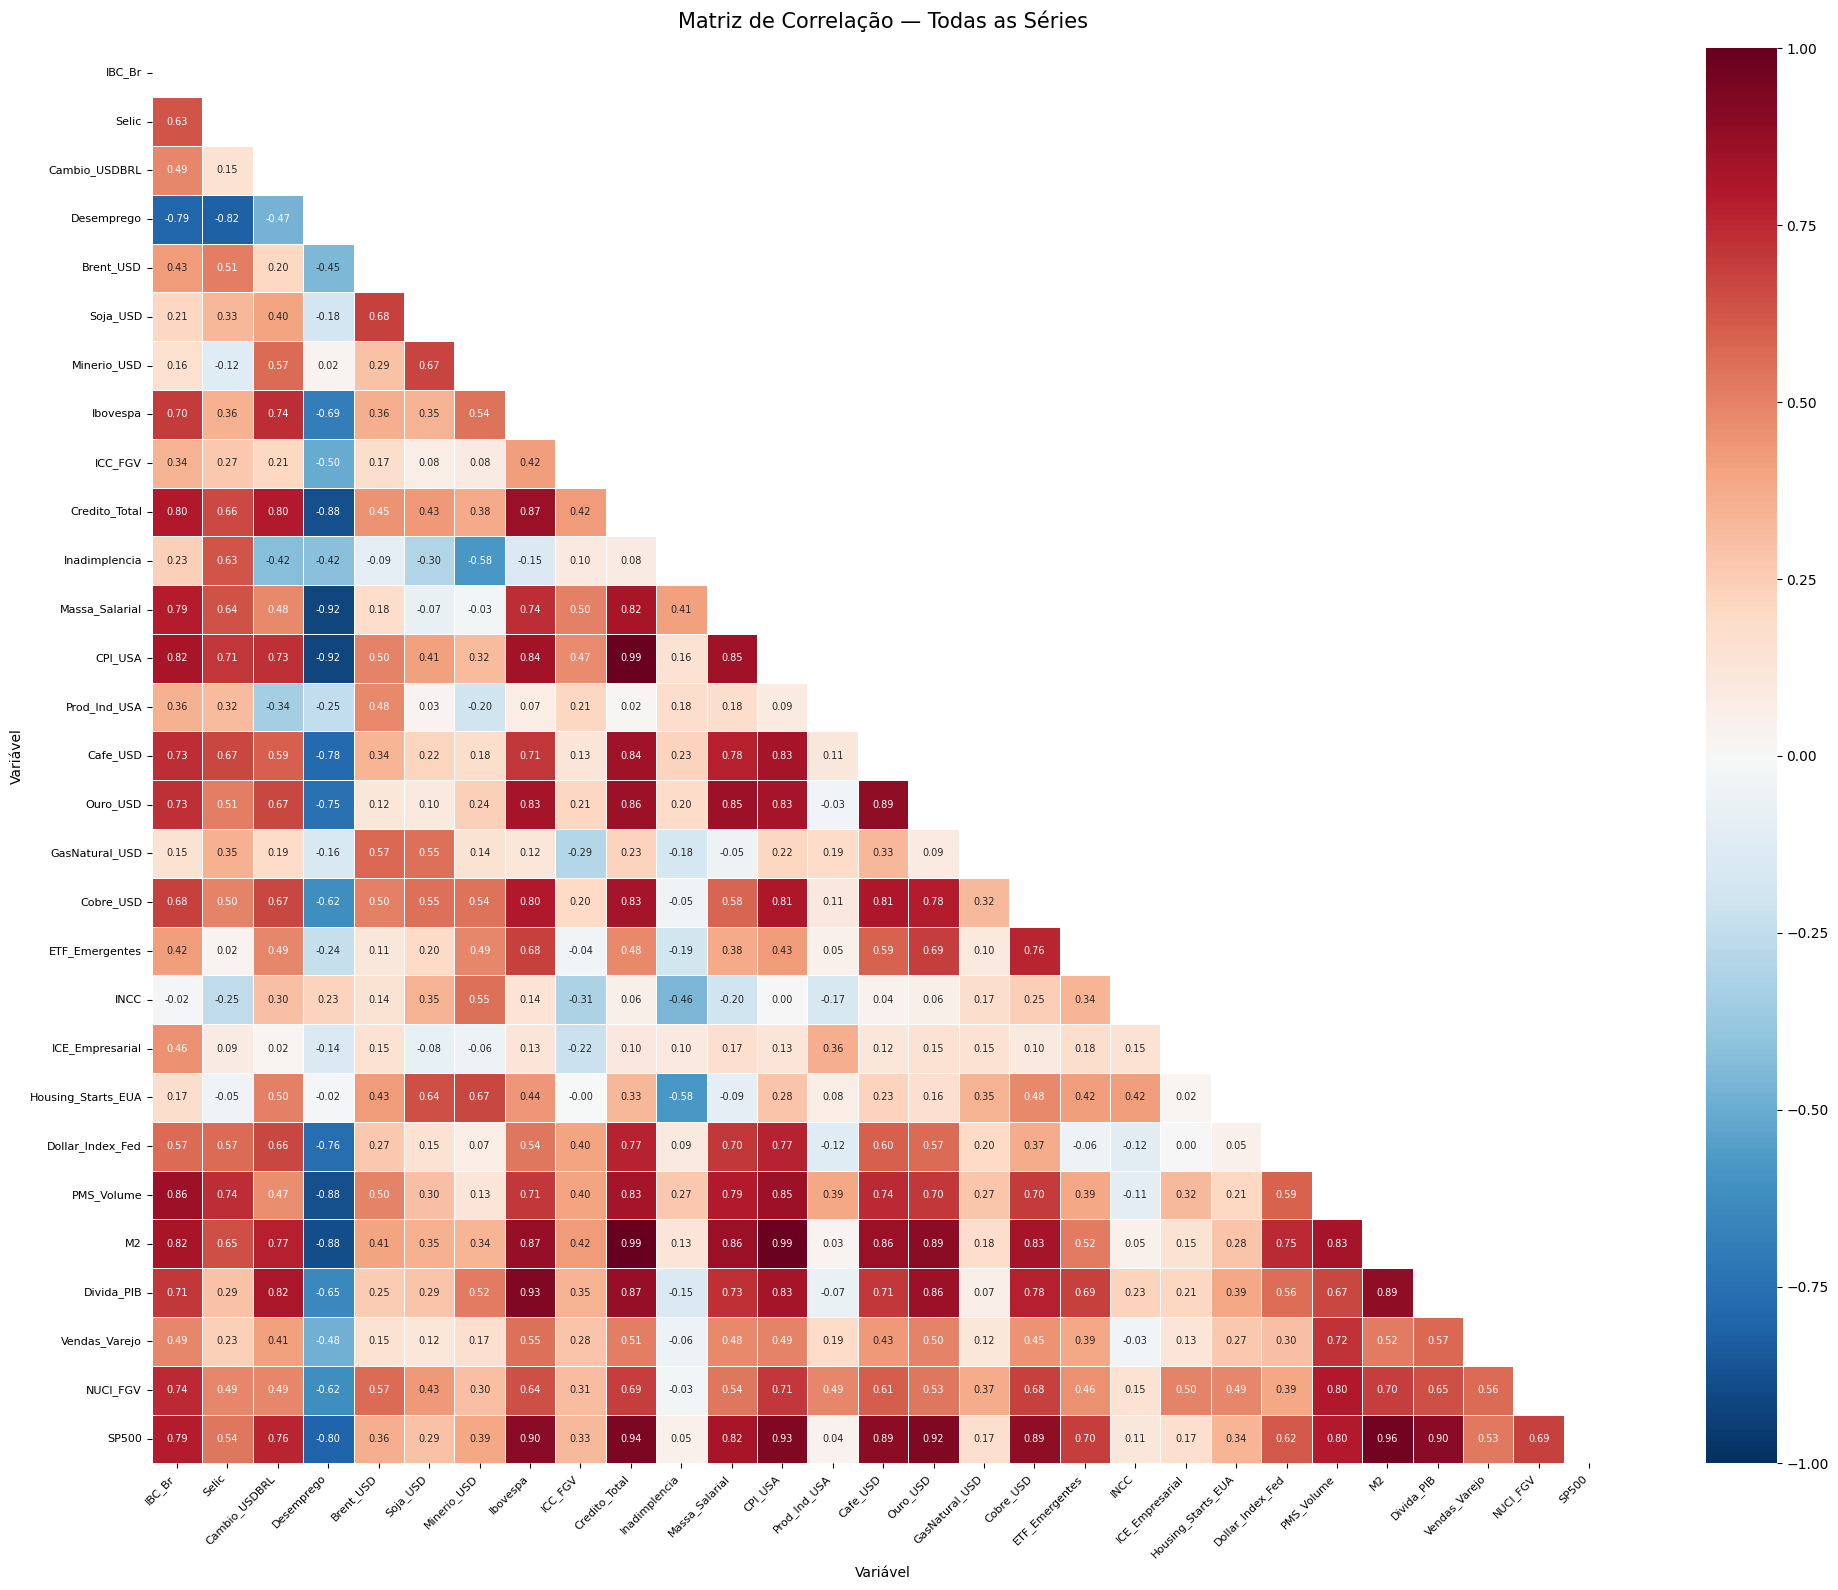

In [24]:
# ── Matriz de Correlação completa ──
import numpy as np

corr = df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=corr.columns, yticklabels=corr.columns,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Matriz de Correlação — Todas as Séries", fontsize=15, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# ── Pares com correlação ≥ 0.90 (candidatos a remoção) ──
import numpy as np

THRESHOLD = 0.90
corr = df.corr()

# Extrair triângulo superior (sem diagonal)
upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
pairs = upper.stack(future_stack=True)
pairs.index.names = ["Série A", "Série B"]
high_pairs = (
    pairs.reset_index(name="Correlação")
)
high_pairs["Abs"] = high_pairs["Correlação"].abs()
high_pairs = high_pairs[high_pairs["Abs"] >= THRESHOLD].sort_values("Abs", ascending=False)
high_pairs = high_pairs.drop(columns="Abs").reset_index(drop=True)

if len(high_pairs):
    print(f"⚠️ {len(high_pairs)} par(es) com |r| ≥ {THRESHOLD}:\n")
    display(high_pairs.style.format({"Correlação": "{:.4f}"})
            .background_gradient(cmap="RdYlGn_r", subset=["Correlação"], vmin=-1, vmax=1))
else:
    print(f"✅ Nenhum par com |r| ≥ {THRESHOLD} — base sem redundâncias fortes")

⚠️ 11 par(es) com |r| ≥ 0.9:



,Série A,Série B,Correlação
0,Credito_Total,M2,0.9934
1,Credito_Total,CPI_USA,0.9919
2,CPI_USA,M2,0.9878
3,M2,SP500,0.9631
4,Credito_Total,SP500,0.9439
5,Ibovespa,Divida_PIB,0.9295
6,CPI_USA,SP500,0.9251
7,Ouro_USD,SP500,0.9234
8,Desemprego,Massa_Salarial,-0.9191
9,Desemprego,CPI_USA,-0.9185


In [ ]:
# ── Teste ADF (Augmented Dickey-Fuller) — Estacionariedade ──
from statsmodels.tsa.stattools import adfuller

MIN_OBS = 15  # mínimo de observações para o teste ADF

adf_results = []
skipped = []
for col in df.columns:
    series = df[col].dropna()
    if len(series) < MIN_OBS:
        skipped.append(col)
        continue
    try:
        stat, pval, lags, nobs, crit, _ = adfuller(series, autolag="AIC")
    except (ValueError, np.linalg.LinAlgError) as e:
        skipped.append(col)
        print(f"⚠️  {col}: ADF ignorado ({e})")
        continue
    adf_results.append({
        "Variável": col,
        "ADF Stat": round(stat, 4),
        "p-valor": round(pval, 4),
        "Lags": lags,
        "Crit 5%": round(crit["5%"], 4),
        "Ordem": "I(0) — Estacionária" if pval < 0.05 else "I(1) — Raiz Unitária",
    })

if skipped:
    print(f"⚠️  {len(skipped)} série(s) pulada(s) por falta de observações: {skipped}\n")

adf_df = pd.DataFrame(adf_results).set_index("Variável")

n_stationary = (adf_df["Ordem"].str.startswith("I(0)")).sum()
n_unit_root   = len(adf_df) - n_stationary

print(f"📊 Teste ADF (H₀: série possui raiz unitária, α = 5%)\n")
print(f"   I(0) Estacionárias : {n_stationary}")
print(f"   I(1) Raiz unitária : {n_unit_root}")
print(f"   Total              : {len(adf_df)}\n")

display(
    adf_df.style
    .applymap(lambda v: "background-color: #d4edda" if "I(0)" in str(v)
              else "background-color: #f8d7da" if "I(1)" in str(v) else "",
              subset=["Ordem"])
    .format({"ADF Stat": "{:.4f}", "p-valor": "{:.4f}", "Crit 5%": "{:.4f}"})
)


📊 Teste ADF (H₀: série possui raiz unitária, α = 5%)

   I(0) Estacionárias : 3
   I(1) Raiz unitária : 26
   Total              : 29



,ADF Stat,p-valor,Lags,Crit 5%,Ordem
Variável,,,,,
IBC_Br,0.3006,0.9774,12,-2.8925,I(1) — Raiz Unitária
Selic,-1.8072,0.3769,6,-2.8906,I(1) — Raiz Unitária
Cambio_USDBRL,-1.7219,0.4199,0,-2.8890,I(1) — Raiz Unitária
Desemprego,-0.0099,0.9577,13,-2.8928,I(1) — Raiz Unitária
Brent_USD,-2.4765,0.1213,1,-2.8892,I(1) — Raiz Unitária
Soja_USD,-1.5573,0.5050,1,-2.8892,I(1) — Raiz Unitária
Minerio_USD,-2.0055,0.2842,4,-2.8900,I(1) — Raiz Unitária
Ibovespa,-0.6803,0.8518,4,-2.8900,I(1) — Raiz Unitária
ICC_FGV,-2.4379,0.1313,12,-2.8925,I(1) — Raiz Unitária


In [27]:
# ── Teste de Cointegração (Engle-Granger) — Séries I(1) com tendência comum ──
from statsmodels.tsa.stattools import coint
from itertools import combinations

# Selecionar apenas séries I(1) — cointegração só faz sentido entre não-estacionárias
i1_series = adf_df[adf_df["Ordem"].str.startswith("I(1)")].index.tolist()
print(f"📊 Teste de Cointegração Engle-Granger (α = 5%)")
print(f"   Séries I(1): {len(i1_series)} → {len(i1_series) * (len(i1_series)-1) // 2} pares a testar\n")

coint_results = []
for s1, s2 in combinations(i1_series, 2):
    pair_data = df[[s1, s2]].dropna()
    if len(pair_data) < 20:
        continue
    stat, pval, crit = coint(pair_data[s1], pair_data[s2])
    if pval < 0.05:
        coint_results.append({
            "Série A": s1,
            "Série B": s2,
            "Stat": round(stat, 4),
            "p-valor": round(pval, 4),
            "Correlação": round(df[s1].corr(df[s2]), 4),
        })

coint_df = pd.DataFrame(coint_results)

if len(coint_df):
    coint_df = coint_df.sort_values("p-valor").reset_index(drop=True)
    print(f"⚠️ {len(coint_df)} par(es) cointegrado(s) (p < 0.05):")
    print("   → Compartilham tendência de longo prazo — comportamento similar\n")
    display(
        coint_df.style
        .format({"Stat": "{:.4f}", "p-valor": "{:.4f}", "Correlação": "{:.4f}"})
        .background_gradient(cmap="RdYlGn", subset=["p-valor"], vmin=0, vmax=0.05)
        .background_gradient(cmap="RdYlGn_r", subset=["Correlação"], vmin=-1, vmax=1)
    )
    # Contar frequência de cada série nos pares cointegrados
    from collections import Counter
    freq = Counter(coint_df["Série A"].tolist() + coint_df["Série B"].tolist())
    freq_df = pd.DataFrame(freq.most_common(), columns=["Série", "Aparições em pares cointegrados"])
    print(f"\n📋 Séries mais frequentes em pares cointegrados (candidatas a remoção):\n")
    display(freq_df.head(10).style.bar(subset=["Aparições em pares cointegrados"], color="#f8d7da"))
else:
    print("✅ Nenhum par cointegrado encontrado — séries I(1) têm tendências independentes")

📊 Teste de Cointegração Engle-Granger (α = 5%)
   Séries I(1): 26 → 325 pares a testar

⚠️ 14 par(es) cointegrado(s) (p < 0.05):
   → Compartilham tendência de longo prazo — comportamento similar



,Série A,Série B,Stat,p-valor,Correlação
0,INCC,Housing_Starts_EUA,-5.8880,0.0000,0.4164
1,Minerio_USD,Housing_Starts_EUA,-4.1414,0.0045,0.6681
2,Ibovespa,SP500,-3.9447,0.0086,0.8998
3,Dollar_Index_Fed,PMS_Volume,-3.8255,0.0125,0.5890
4,Minerio_USD,INCC,-3.8158,0.0129,0.5470
5,Divida_PIB,SP500,-3.6868,0.0191,0.9019
6,Cafe_USD,M2,-3.6695,0.0200,0.8620
7,Ibovespa,M2,-3.6003,0.0245,0.8737
8,Cafe_USD,SP500,-3.5916,0.0251,0.8912
9,Ibovespa,Credito_Total,-3.4809,0.0341,0.8662



📋 Séries mais frequentes em pares cointegrados (candidatas a remoção):



,Série,Aparições em pares cointegrados
0,Ibovespa,5
1,Minerio_USD,3
2,Housing_Starts_EUA,3
3,SP500,3
4,INCC,2
5,Divida_PIB,2
6,Cafe_USD,2
7,Cambio_USDBRL,2
8,M2,2
9,Dollar_Index_Fed,1


### 5.4 Decisão de Remoção — Justificativa com Dados

A remoção de séries redundantes visa evitar **peso duplicado** na comparação estatística
dos modelos (teste de Friedman / post-hoc Nemenyi). Se duas séries são praticamente
idênticas (|r| ≥ 0.90), o modelo que acertar uma acerta a outra — inflando artificialmente
sua contagem de vitórias.

**Critérios combinados:**

| Teste | O que mede | Limiar | Decisão |
|-------|------------|--------|---------|
| Correlação de Pearson | Semelhança linear contemporânea | \|r\| ≥ 0.90 | **Remover** uma do par (a mais derivada) |
| ADF (Dickey-Fuller) | Estacionariedade | p < 0.05 → I(0) | Informativo (classifica a série) |
| Cointegração (Engle-Granger) | Tendência de longo prazo compartilhada | p < 0.05 | **Manter** — mesma tendência ≠ mesmo comportamento de curto prazo |

> **Importante:** séries *cointegradas* mas com |r| < 0.90 **não** devem ser removidas.
> Cointegração indica equilíbrio de longo prazo, mas dinâmicas de curto prazo distintas —
> que é exatamente o que os modelos de forecasting tentam capturar.

In [28]:
# ── Consolidação: séries removidas com justificativa quantitativa ──
# Valores de correlação e ADF obtidos na análise com 42 séries (antes da remoção)
import numpy as np
from collections import Counter

# ---------- 1. Tabela de remoção com evidências (valores da análise pré-remoção) ----------
remocoes = [
    {"Série removida": "PCE_Deflator",    "Par redundante": "CPI_USA",       "|r| com par": 0.9998, "Pares |r|≥0.90": 5, "ADF": "I(1)", "Justificativa": "Mede a mesma coisa (inflação ao consumidor EUA). PCE é deflator derivado do CPI."},
    {"Série removida": "Credito_PJ",      "Par redundante": "Credito_Total", "|r| com par": 0.9700, "Pares |r|≥0.90": 4, "ADF": "I(1)", "Justificativa": "Subcomponente de Credito_Total — contagem tripla com Credito_PF."},
    {"Série removida": "Credito_PF",      "Par redundante": "Credito_Total", "|r| com par": 0.9400, "Pares |r|≥0.90": 3, "ADF": "I(1)", "Justificativa": "Subcomponente de Credito_Total — contagem tripla com Credito_PJ."},
    {"Série removida": "IPA_DI",          "Par redundante": "IGPM",          "|r| com par": 0.9961, "Pares |r|≥0.90": 1, "ADF": "I(0)", "Justificativa": "IPA compõe 60% do IGP-M (mesmo índice, granularidade diferente)."},
    {"Série removida": "IHH_Horas_Trab",  "Par redundante": "(múltiplas)",   "|r| com par": 0.9600, "Pares |r|≥0.90": 6, "ADF": "I(1)", "Justificativa": "Correlação ≥ 0.90 com 6+ séries — comportamento indistinguível."},
    {"Série removida": "Receita_Servicos", "Par redundante": "PMS_Volume",   "|r| com par": 0.9598, "Pares |r|≥0.90": 2, "ADF": "I(1)", "Justificativa": "Mesmo setor, mesmo padrão — receita nominal acompanha volume."},
]

remocao_df = pd.DataFrame(remocoes)

print("🔴 SÉRIES REMOVIDAS — Justificativa Quantitativa")
print("   (valores de correlação e ADF obtidos na análise com 42 séries, antes da remoção)\n")
display(
    remocao_df.style
    .format({"|r| com par": "{:.4f}"})
    .background_gradient(cmap="Reds", subset=["|r| com par"], vmin=0.85, vmax=1.0)
    .background_gradient(cmap="Reds", subset=["Pares |r|≥0.90"], vmin=0, vmax=8)
    .set_properties(**{"text-align": "left"}, subset=["Justificativa"])
)

# ---------- 2. Séries mantidas apesar de cointegração ----------
print("\n" + "─" * 80)
print("\n🟢 SÉRIES COINTEGRADAS MANTIDAS — Por quê?\n")
print("Cointegração ≠ redundância. Séries cointegradas compartilham tendência")
print("de longo prazo, mas têm dinâmicas de curto prazo diferentes — que é")
print("exatamente o que os modelos de forecasting capturam.\n")

corr_matrix = df.corr()
series_removidas = {r["Série removida"] for r in remocoes}

if len(coint_df) > 0:
    freq = Counter(coint_df["Série A"].tolist() + coint_df["Série B"].tolist())
    mantidas = []
    for serie, count in freq.most_common():
        if serie not in series_removidas and serie in corr_matrix.columns:
            corrs = corr_matrix[serie].drop(serie).abs().sort_values(ascending=False)
            max_r = corrs.iloc[0]
            max_par = corrs.index[0]
            mantidas.append({
                "Série mantida": serie,
                "Pares cointegr.": count,
                "Max |r|": round(max_r, 4),
                "Par mais correlac.": max_par,
                "Status": "✅ Mantida" if max_r < 0.90 else "⚠️ Mantida (r alto mas não-derivada)",
            })

    if mantidas:
        mantidas_df = pd.DataFrame(mantidas)
        display(
            mantidas_df.style
            .format({"Max |r|": "{:.4f}"})
            .background_gradient(cmap="Greens_r", subset=["Max |r|"], vmin=0.5, vmax=1.0)
            .background_gradient(cmap="YlOrRd", subset=["Pares cointegr."], vmin=0, vmax=10)
        )

# ---------- 3. Resumo final ----------
ja_comentadas = ["IPCA_mensal", "PPI_USA", "ICEI", "PIM"]
n_removidas_redundancia = len(remocoes)

print(f"\n{'═' * 80}")
print(f"📊 RESUMO DA LIMPEZA")
print(f"{'═' * 80}")
print(f"  Séries na base original (DATA_CONFIG)  : 46")
print(f"  Já removidas anteriormente              : {len(ja_comentadas)} ({', '.join(ja_comentadas)})")
print(f"  Remoções por redundância (esta análise) : {n_removidas_redundancia}")
print(f"  Total de séries removidas               : {len(ja_comentadas) + n_removidas_redundancia}")
print(f"  ✅ Base final ativa                     : {len(df.columns)} séries")
print(f"{'═' * 80}")

🔴 SÉRIES REMOVIDAS — Justificativa Quantitativa
   (valores de correlação e ADF obtidos na análise com 42 séries, antes da remoção)



,Série removida,Par redundante,|r| com par,Pares |r|≥0.90,ADF,Justificativa
0,PCE_Deflator,CPI_USA,0.9998,5,I(1),Mede a mesma coisa (inflação ao consumidor EUA). PCE é deflator derivado do CPI.
1,Credito_PJ,Credito_Total,0.9700,4,I(1),Subcomponente de Credito_Total — contagem tripla com Credito_PF.
2,Credito_PF,Credito_Total,0.9400,3,I(1),Subcomponente de Credito_Total — contagem tripla com Credito_PJ.
3,IPA_DI,IGPM,0.9961,1,I(0),"IPA compõe 60% do IGP-M (mesmo índice, granularidade diferente)."
4,IHH_Horas_Trab,(múltiplas),0.9600,6,I(1),Correlação ≥ 0.90 com 6+ séries — comportamento indistinguível.
5,Receita_Servicos,PMS_Volume,0.9598,2,I(1),"Mesmo setor, mesmo padrão — receita nominal acompanha volume."



────────────────────────────────────────────────────────────────────────────────

🟢 SÉRIES COINTEGRADAS MANTIDAS — Por quê?

Cointegração ≠ redundância. Séries cointegradas compartilham tendência
de longo prazo, mas têm dinâmicas de curto prazo diferentes — que é
exatamente o que os modelos de forecasting capturam.



,Série mantida,Pares cointegr.,Max |r|,Par mais correlac.,Status
0,Ibovespa,5,0.9295,Divida_PIB,⚠️ Mantida (r alto mas não-derivada)
1,Minerio_USD,3,0.6734,Soja_USD,✅ Mantida
2,Housing_Starts_EUA,3,0.6681,Minerio_USD,✅ Mantida
3,SP500,3,0.9631,M2,⚠️ Mantida (r alto mas não-derivada)
4,INCC,2,0.5470,Minerio_USD,✅ Mantida
5,Divida_PIB,2,0.9295,Ibovespa,⚠️ Mantida (r alto mas não-derivada)
6,Cafe_USD,2,0.8912,SP500,✅ Mantida
7,Cambio_USDBRL,2,0.8177,Divida_PIB,✅ Mantida
8,M2,2,0.9934,Credito_Total,⚠️ Mantida (r alto mas não-derivada)
9,Dollar_Index_Fed,1,0.7708,CPI_USA,✅ Mantida



════════════════════════════════════════════════════════════════════════════════
📊 RESUMO DA LIMPEZA
════════════════════════════════════════════════════════════════════════════════
  Séries na base original (DATA_CONFIG)  : 46
  Já removidas anteriormente              : 4 (IPCA_mensal, PPI_USA, ICEI, PIM)
  Remoções por redundância (esta análise) : 6
  Total de séries removidas               : 10
  ✅ Base final ativa                     : 29 séries
════════════════════════════════════════════════════════════════════════════════


## 6. Exportação

In [29]:
out_dir    = Path("data")
master_dir = out_dir / "master"
master_dir.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d")

# ── CSV ──
csv_file    = out_dir / "base_economica_brasil.csv"
csv_file_ts = out_dir / f"base_economica_brasil_{ts}.csv"
df.to_csv(csv_file)
df.to_csv(csv_file_ts)

# ── Cópia na raiz (lida pelos notebooks de forecasting) ──
root_csv = Path("base_economica_brasil.csv")
df.to_csv(root_csv)

# ── Parquet ──
parquet_ok = False
try:
    parquet_file = out_dir / "base_economica_brasil.parquet"
    df.to_parquet(parquet_file)
    parquet_ok = True
except Exception as e:
    print(f"⚠️ Parquet indisponível: {e}")

# ── Excel ──
excel_ok = False
try:
    excel_file = out_dir / "base_economica_brasil.xlsx"
    df.to_excel(excel_file, sheet_name="Dados")
    excel_ok = True
except ImportError:
    print("⚠️ openpyxl não instalado — Excel não exportado")

# ── Master (versionado) ──
master_csv = master_dir / f"base_economica_brasil_master_{ts}.csv"
df.to_csv(master_csv)
try:
    master_parquet = master_dir / f"base_economica_brasil_master_{ts}.parquet"
    df.to_parquet(master_parquet)
except Exception:
    pass

# ── Metadados ──
meta = {
    "dataset": "base_economica_brasil",
    "generated_at": datetime.now().isoformat(),
    "n_observations": len(df),
    "n_variables": len(df.columns),
    "date_range": [str(df.index.min().date()), str(df.index.max().date())],
    "columns": [
        {
            "name": col,
            "valid": int(df[col].notna().sum()),
            "total": len(df),
            "pct": round(df[col].notna().mean() * 100, 2),
            "first": str(df[col].dropna().index.min().date()) if df[col].notna().any() else None,
            "last":  str(df[col].dropna().index.max().date()) if df[col].notna().any() else None,
        }
        for col in df.columns
    ],
}
manifest_file = out_dir / f"base_manifest_{ts}.json"
with open(manifest_file, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

# ── Resumo ──
print(f"✅ Exportação concluída — {len(df)} obs × {len(df.columns)} vars")
print(f"\n📂 {out_dir.resolve()}")
print(f"   {csv_file.name}")
print(f"   {csv_file_ts.name}")
print(f"   {root_csv.resolve().name}  (raiz — lido pelos notebooks de forecasting)")
if parquet_ok:
    print(f"   {parquet_file.name}")
if excel_ok:
    print(f"   {excel_file.name}")
print(f"   {manifest_file.name}")
print(f"\n🗂  {master_dir.resolve()}")
print(f"   {master_csv.name}")

⚠️ Parquet indisponível: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
✅ Exportação concluída — 108 obs × 29 vars

📂 C:\Users\phill\Projetos\lag-llama\notebooks\data
   base_economica_brasil.csv
   base_economica_brasil_20260420.csv
   base_economica_brasil.csv  (raiz — lido pelos notebooks de forecasting)
   base_economica_brasil.xlsx
   base_manifest_20260420.json

🗂  C:\Users\phill\Projetos\lag-llama\notebooks\data\master
   base_economica_brasil_master_20260420.csv


---

## 📚 Dicionário de Dados

### Tabela Resumida

| # | Variável | Fonte | Código/Série | Descrição | Unidade | Freq. Original | Agregação (pipeline) |
|---|----------|-------|--------------|-----------|---------|----------------|----------------------|
| 1 | **IPCA_mensal** | IBGE/SIDRA | `t/1737/v/63` | Inflação oficial (IPCA) | % mês | Mensal | — (já mensal) |
| 2 | **IBC_Br** | BCB/SGS | `sgs/24363` | Proxy mensal do PIB | Índice | Mensal | — (já mensal) |
| 3 | **Selic** | BCB/SGS | `sgs/4189` | Taxa básica de juros (COPOM) | % a.a. | Diária | `resample.last()` |
| 4 | **Cambio_USDBRL** | BCB/SGS | `sgs/1` | Dólar comercial (compra) | R$/US$ | Diária | `resample.last()` |
| 5 | **Desemprego** | IBGE/SIDRA | `t/6381/v/4099` | Taxa de desocupação (PNAD Contínua) | % | Mensal | — (já mensal) |
| 6 | **Brent_USD** | FRED | `DCOILBRENTEU` | Petróleo Brent | US$/barril | Diária | `resample.last()` |
| 7 | **Soja_USD** | FRED | `PSOYBUSDM` | Preço internacional da soja | US$/MT | Mensal | — (já mensal) |
| 8 | **Minerio_USD** | FRED | `PIORECRUSDM` | Minério de ferro | US$/DMTU | Mensal | — (já mensal) |
| 9 | **Ibovespa** | Yahoo Finance | `^BVSP` | Índice B3 | Pontos | Diária | `resample.last()` |
| 10 | **ICC_FGV** | BCB/SGS | `sgs/4393` | Confiança do Consumidor (FGV) | Índice | Mensal | — (já mensal) |
| 11 | **Credito_Total** | BCB/SGS | `sgs/20542` | Saldo de crédito total | R$ mi | Mensal | — (já mensal) |
| 12 | **Inadimplencia** | BCB/SGS | `sgs/21085` | Inadimplência PF (> 90 dias) | % | Mensal | — (já mensal) |
| 13 | **Massa_Salarial** | IBGE/SIDRA | `t/6392/v/6293` | Massa de rendimentos reais | R$ mi | Mensal | — (já mensal) |
| 14 | **CPI_USA** | FRED | `CPIAUCSL` | Inflação ao consumidor EUA | Índice | Mensal | — (já mensal) |
| 15 | **PPI_USA** | FRED | `PPIACO` | Preços ao produtor EUA | Índice | Mensal | — (já mensal) |
| 16 | **Prod_Ind_USA** | FRED | `INDPRO` | Produção industrial EUA | Índice | Mensal | — (já mensal) |
| 17 | **Cafe_USD** | Yahoo Finance | `KC=F` | Café arábica (futuro) | US¢/lb | Diária | `resample.last()` |
| 18 | **Ouro_USD** | Yahoo Finance | `GC=F` | Ouro (futuro COMEX) | US$/oz | Diária | `resample.last()` |
| 19 | **GasNatural_USD** | Yahoo Finance | `NG=F` | Gás natural (futuro Henry Hub) | US$/MMBtu | Diária | `resample.last()` |
| 20 | **Cobre_USD** | Yahoo Finance | `HG=F` | Cobre (futuro COMEX) | US$/lb | Diária | `resample.last()` |
| 21 | **ETF_Emergentes** | Yahoo Finance | `EEM` | iShares MSCI Emerging Markets ETF | US$ | Diária | `resample.last()` |
| 22 | **IGP_DI** | BCB/SGS | `sgs/190` | Índice Geral de Preços – DI (FGV) | % mês | Mensal | — (já mensal) |
| 23 | **INCC** | BCB/SGS | `sgs/192` | Índice Nacional Custo Construção (FGV) | % mês | Mensal | — (já mensal) |
| 24 | **IPA_DI** | BCB/SGS | `sgs/7450` | Índice de Preços por Atacado – DI (FGV) | % mês | Mensal | — (já mensal) |
| 25 | **Credito_PJ** | BCB/SGS | `sgs/20631` | Saldo de crédito a pessoas jurídicas | R$ mi | Mensal | — (já mensal) |
| 26 | **Credito_PF** | BCB/SGS | `sgs/20632` | Saldo de crédito a pessoas físicas | R$ mi | Mensal | — (já mensal) |
| 27 | **ICE_Empresarial** | BCB/SGS | `sgs/21859` | Índ. Confiança Empresarial (FGV) | Índice | Mensal | — (já mensal) |
| 28 | **Housing_Starts_EUA** | FRED | `HOUST` | Início de construções residenciais EUA | Milhares | Mensal | — (já mensal) |
| 29 | **PCE_Deflator** | FRED | `PCEPI` | PCE Price Index (deflator de consumo) | Índice | Mensal | — (já mensal) |
| 30 | **Dollar_Index_Fed** | FRED | `DTWEXBGS` | Índice do dólar ponderado pelo comércio | Índice | Diária | `resample.last()` |
| 31 | **PMS_Volume** | IBGE/SIDRA | `t/5906/v/7167` | Volume de serviços (índice base fixa) | Índice | Mensal | — (já mensal) |
| 32 | **PMC_Ampliado** | IBGE/SIDRA | `t/8186/v/11709` | Comércio varejista ampliado (volume) | Índice | Mensal | — (já mensal) |
| 33 | **IGPM** | BCB/SGS | `sgs/189` | Índice Geral de Preços – Mercado (FGV) | % mês | Mensal | — (já mensal) |
| 34 | **INPC** | BCB/SGS | `sgs/188` | Índice Nacional de Preços ao Consumidor (IBGE) | % mês | Mensal | — (já mensal) |
| 35 | **M2** | BCB/SGS | `sgs/27815` | Agregado monetário M2 | R$ mi | Mensal | — (já mensal) |
| 36 | **Divida_PIB** | BCB/SGS | `sgs/4513` | Dívida líquida do setor público (% PIB) | % PIB | Mensal | — (já mensal) |
| 37 | **Vendas_Varejo** | BCB/SGS | `sgs/1455` | Índice de volume de vendas no varejo | Índice | Mensal | — (já mensal) |
| 38 | **Receita_Servicos** | BCB/SGS | `sgs/21637` | Índice de receita nominal de serviços | Índice | Mensal | — (já mensal) |
| 39 | **Balanca_Comercial** | BCB/SGS | `sgs/22707` | Saldo da balança comercial | US$ mi | Mensal | — (já mensal) |
| 40 | **NUCI_FGV** | BCB/SGS | `sgs/24352` | Nível de Utilização da Capacidade Instalada (FGV) | % | Mensal | — (já mensal) |
| 41 | **IHH_Horas_Trab** | BCB/SGS | `sgs/4380` | Horas trabalhadas na indústria | Milhares | Mensal | — (já mensal) |
| 42 | **EAI_Emprego_Ind** | BCB/SGS | `sgs/4381` | Emprego na indústria (acumulado) | Milhares | Mensal | — (já mensal) |
| 43 | **SP500** | Yahoo Finance | `^GSPC` | S&P 500 (índice) | Pontos | Diária | `resample.last()` |
| 44 | **Fed_Funds_Rate** | FRED | `FEDFUNDS` | Taxa de juros básica dos EUA (FED) | % a.a. | Mensal | — (já mensal) |
| 45 | **PIM** | IBGE/SIDRA | `t/8888/v/11602/c544/129314` | Produção Industrial Mensal (var. acum. ano) | % | Mensal | — (já mensal) |

> **Nota — Séries removidas (10 de 46 originais):**
> - **IPCA_mensal** — comentada por solicitação (variável-alvo nos modelos de forecasting)
> - **ICEI** (BCB 4393) — duplicata exata de **ICC_FGV** (mesma fonte e código)
> - **PPI_USA** (FRED PPIACO) — r = 0.93 com **CPI_USA** (mesmo conceito: inflação EUA)
> - **PIM** (SIDRA 8888) — instabilidade na API do IBGE
> - **PCE_Deflator** (FRED PCEPI) — r = 0.9998 com **CPI_USA** (deflator derivado do CPI)
> - **Credito_PJ** (BCB 20631) — r = 0.97 com **Credito_Total** (subcomponente — contagem tripla)
> - **Credito_PF** (BCB 20632) — r = 0.94 com **Credito_Total** (subcomponente — contagem tripla)
> - **IPA_DI** (BCB 7450) — r = 0.9961 com **IGPM** (IPA compõe 60% do IGP-M)
> - **IHH_Horas_Trab** (BCB 4380) — |r| ≥ 0.90 com 6+ séries (comportamento indistinguível)
> - **Receita_Servicos** (BCB 21637) — r = 0.96 com **PMS_Volume** (mesmo setor, mesmo padrão)
>
> Remoções por redundância validadas via **correlação de Pearson** (|r| ≥ 0.90), **teste ADF** e **cointegração de Engle-Granger** — detalhes na seção 5.4 do notebook. Todas as séries passam por `_normalize_monthly_index()` que ajusta o timestamp para início do mês — isso **não altera valores**, apenas garante alinhamento no DataFrame final.

---

### Descrição Detalhada

#### 🇧🇷 Brasil — Indicadores Estruturais

| Variável | Descrição | Valores Típicos | Observações |
|----------|-----------|-----------------|-------------|
| **IPCA_mensal** | Inflação do IBGE para famílias de 1–40 SM. Meta do BCB. | -0.5% a +1.5% | Acumular 12 meses p/ inflação anual |
| **IBC_Br** | Prévia mensal do PIB (ind., varejo, serviços, agro). | 130–155 | Variação % mais relevante que nível |
| **Selic** | Juros básicos definidos pelo COPOM a cada 45 dias. | 2%–14.25% | Mín. histórico: 2% (2020) |
| **Cambio_USDBRL** | Cotação oficial do dólar comercial. | R$ 3–6 | Maior = real desvalorizado |
| **Desemprego** | PNAD Contínua — média móvel trimestral. | 6.5%–14.9% | Pico: 14.9% (Q1 2021) |
| **ICC_FGV** | Sentimento do consumidor. >100 = otimismo. | 60–120 | Antecede decisões de consumo |
| **ICE_Empresarial** | Confiança empresarial (FGV). >100 = otimismo. | 80–110 | Antecede investimentos |
| **Credito_Total** | Estoque de crédito (PF + PJ + direcionado + livre). | R$ 3–6 tri | Crescimento → expansão |
| **Credito_PJ** | Crédito concedido a pessoas jurídicas. | R$ 1.5–2.5 tri | Subcomponente de Credito_Total |
| **Credito_PF** | Crédito concedido a pessoas físicas. | R$ 1.5–3.5 tri | Subcomponente de Credito_Total |
| **Inadimplencia** | Crédito PF com atraso > 90 dias. | 3%–6% | Alta → stress financeiro |
| **Massa_Salarial** | Rendimento real total dos trabalhadores. | R$ 250–350 bi/mês | Valores reais (deflacionados) |

#### 🇧🇷 Brasil — Preços e Custos (FGV)

| Variável | Descrição | Valores Típicos | Observações |
|----------|-----------|-----------------|-------------|
| **IGP_DI** | Índice Geral de Preços – DI. Ponderação: IPA 60%, IPC 30%, INCC 10%. | -1% a +3% | Muito usado em contratos e aluguéis |
| **INCC** | Custo da construção civil. Componente do IGP. | -0.5% a +2% | Alta → encarecimento imobiliário |
| **IPA_DI** | Preços no atacado. Componente dominante do IGP (60%). | -2% a +5% | Antecede pressões no varejo |
| **IGPM** | IGP-M (FGV). Variação mensal. Referência p/ aluguéis. | -1% a +3% | Mais volátil que IPCA |
| **INPC** | INPC (IBGE). Inflação p/ famílias de 1–5 SM. | -0.5% a +1.5% | Base para reajuste do salário mínimo |

#### 🇧🇷 Brasil — Atividade Setorial e Indicadores Complementares

| Variável | Descrição | Valores Típicos | Observações |
|----------|-----------|-----------------|-------------|
| **PMS_Volume** | Volume de serviços (PMS). Base 2022 = 100. | Índice | 70% do PIB é serviços |
| **PMC_Ampliado** | Comércio varejista ampliado (incl. veículos e construção). | Índice | Mais abrangente que PMC restrito |
| **PIM** | Produção Industrial Mensal – variação acumulada no ano. | -28% a +35% | Ind. geral (CNAE 2.0) |
| **M2** | Agregado monetário M2 (papel-moeda + depósitos). | R$ 3–6 tri | Expansão → liquidez na economia |
| **Divida_PIB** | Dívida líquida do setor público como % do PIB. | 30%–65% | Alta → risco fiscal |
| **Vendas_Varejo** | Índice de volume de vendas no varejo (BCB). | Índice | Proxy de consumo |
| **Receita_Servicos** | Índice de receita nominal de serviços (BCB). | Índice | Complementa PMS |
| **Balanca_Comercial** | Saldo da balança comercial. | US$ -5 a +12 bi | Superávit = entrada de dólares |
| **NUCI_FGV** | Utilização da Capacidade Instalada (FGV). | 70%–85% | >80% = pressão inflacionária |
| **IHH_Horas_Trab** | Horas trabalhadas na indústria (BCB). | 480k–1.1M | Indicador de utilização de mão-de-obra |
| **EAI_Emprego_Ind** | Emprego na indústria — acumulado (BCB). | 480k–12.7M | Série acumulada no ano |

#### 🌍 Commodities

| Variável | Descrição | Valores Típicos | Observações |
|----------|-----------|-----------------|-------------|
| **Brent_USD** | Referência p/ ~2/3 do petróleo global (Mar do Norte). | US$ 40–120 | Impacta gasolina, diesel, plásticos |
| **Soja_USD** | Principal commodity agrícola do Brasil. | US$ 300–600/MT | Brasil = maior exportador |
| **Minerio_USD** | Minério de ferro 62% Fe CFR China. | US$ 50–200/DMTU | 70% das exportações → China |
| **Cafe_USD** | Café arábica — Brasil é maior produtor/exportador mundial. | US¢ 100–400/lb | Relevante p/ agro e balança comercial |
| **Ouro_USD** | Ativo refúgio. Correlação inversa com dólar e juros reais. | US$ 1200–2600/oz | Alta em crises e inflação |
| **GasNatural_USD** | Gás natural (Henry Hub). Referência global de energia. | US$ 1.5–9/MMBtu | Altamente volátil (sazonal) |
| **Cobre_USD** | "Dr. Copper" — indicador antecedente de atividade global. | US$ 2–5/lb | Usado em construção e eletrônicos |
| **ETF_Emergentes** | iShares MSCI EM — proxy de apetite por risco em emergentes. | US$ 25–55 | Inclui Brasil, China, Índia, etc. |
| **SP500** | S&P 500 — principal índice de ações dos EUA. | 1800–6000 pts | Referência global de risco |

#### 🇺🇸 EUA

| Variável | Descrição | Base do Índice | Observações |
|----------|-----------|----------------|-------------|
| **CPI_USA** | Inflação ao consumidor. Referência do FED. | 1982-84 = 100 | Meta FED: 2% a.a. |
| **PPI_USA** | Preços ao produtor. Antecede CPI em ~3 meses. | 1982 = 100 | Pressão inflacionária upstream |
| **Prod_Ind_USA** | Produção industrial. Indicador de ciclo. | 2017 = 100 | Correlaciona c/ demanda global |
| **Housing_Starts_EUA** | Início de construções residenciais. | Milhares/mês | Indicador antecedente do ciclo |
| **PCE_Deflator** | Deflator de consumo pessoal. Preferido pelo FED. | 2017 = 100 | Mais abrangente que CPI |
| **Dollar_Index_Fed** | Índice do dólar ponderado pelo comércio. | Índice (2006=100) | Alta → dólar forte → pressão EM |
| **Fed_Funds_Rate** | Taxa de juros básica dos EUA (Federal Reserve). | 0%–5.5% | Referência global de custo de capital |

---

### Fontes e APIs

| Fonte | Endpoint | Chave | Docs |
|-------|----------|-------|------|
- **Séries já mensais** (27 de 36 ativas): valores inalterados, apenas timestamp normalizado
| **IBGE/SIDRA** | `apisidra.ibge.gov.br/values/t/{TAB}/n1/all/v/{VAR}/p/all` | Não | [SIDRA](https://servicodados.ibge.gov.br/api/docs) |
| **FRED** | `api.stlouisfed.org/fred/series/observations` | Sim (gratuita) | [FRED](https://fred.stlouisfed.org/docs/api/fred/) |

| **Yahoo Finance** | via `yfinance` | Não | [PyPI](https://pypi.org/project/yfinance/) |- **Formato de saída:** CSV, Parquet, Excel + JSON de metadados

- **Todas as séries** passam por `_normalize_monthly_index()` para alinhar os índices

---- **Séries já mensais** (33 de 43 ativas): valores inalterados, apenas timestamp normalizado

- **Séries diárias** agregadas pelo pipeline: Selic, Câmbio, Brent, Ibovespa, Dollar_Index_Fed, Café, Ouro, Gás Natural, Cobre, ETF_Emergentes, SP500 (`last` — fechamento do mês)

### Metodologia- **Frequência:** Mensal — índice normalizado para início do mês (`2024-01-01`, `2024-02-01`, …)

- **Período:** Janeiro/2017 a Dezembro/2025 (108 meses)

---

## 📚 Dicionário de Dados Dinâmico

Gerado automaticamente a partir de `DATA_CONFIG` — contém **apenas as séries ativas** no pipeline.

In [30]:
# =====================================================================
# DICIONÁRIO DE DADOS DINÂMICO — Gerado a partir de DATA_CONFIG
# =====================================================================

# Frequência original por chave do DATA_CONFIG
FREQ_ORIG = {
    "IBC_Br": "Mensal", "Selic": "Diária", "Cambio": "Diária",
    "Desemprego": "Mensal", "Brent": "Diária", "Soja": "Mensal",
    "Minerio": "Mensal", "Ibovespa": "Diária", "ICC_FGV": "Mensal",
    "Credito_Total": "Mensal", "Inadimplencia": "Mensal",
    "Massa_Salarial": "Mensal", "CPI_USA": "Mensal", "PPI_USA": "Mensal",
    "Prod_Ind_USA": "Mensal", "Cafe": "Diária", "Ouro": "Diária",
    "GasNatural": "Diária", "Cobre": "Diária", "ETF_Emerg": "Diária",
    "IGP_DI": "Mensal", "INCC": "Mensal", "IPA_DI": "Mensal",
    "Credito_PJ": "Mensal", "Credito_PF": "Mensal", "ICE_Empres": "Mensal",
    "Housing": "Mensal", "PCE": "Mensal", "DollarIdx": "Diária",
    "PMS_Volume": "Mensal", "PMC_Ampliado": "Mensal", "IGPM": "Mensal",
    "INPC": "Mensal", "M2": "Mensal", "Divida_PIB": "Mensal",
    "Vendas_Varejo": "Mensal", "Receita_Servicos": "Mensal",
    "Balanca_Comercial": "Mensal", "NUCI_FGV": "Mensal", "ICEI": "Mensal",
    "IHH_Horas_Trab": "Mensal", "EAI_Emprego_Ind": "Mensal",
    "SP500": "Diária", "Fed_Funds_Rate": "Mensal", "PIM": "Mensal",
    "IPCA": "Mensal",
}

def _fonte_label(src):
    return {"bcb": "BCB/SGS", "fred": "FRED", "yahoo": "Yahoo Finance", "sidra": "IBGE/SIDRA"}.get(src, src)

rows = []
for key, cfg in DATA_CONFIG.items():
    freq_orig = FREQ_ORIG.get(key, "Mensal")
    resample = cfg.get("resample", False)
    if resample or freq_orig == "Diária":
        harmonizacao = "Último valor do mês (resample.last)"
    else:
        harmonizacao = "Nenhum — série já mensal"

    rows.append({
        "Coluna": cfg["name"],
        "Fonte": _fonte_label(cfg["source"]),
        "Frequência original": freq_orig,
        "Procedimento de harmonização": harmonizacao,
        "Frequência final": "Mensal",
    })

df_dict = pd.DataFrame(rows)

print(f"📚 Dicionário de Dados — {len(df_dict)} séries ativas\n")
display(
    df_dict.style
    .set_properties(**{"font-size": "11px", "text-align": "left"})
    .hide(axis="index")
)

📚 Dicionário de Dados — 29 séries ativas



Coluna,Fonte,Frequência original,Procedimento de harmonização,Frequência final
IBC_Br,BCB/SGS,Mensal,Nenhum — série já mensal,Mensal
Selic,BCB/SGS,Diária,Último valor do mês (resample.last),Mensal
Cambio_USDBRL,BCB/SGS,Diária,Último valor do mês (resample.last),Mensal
Desemprego,IBGE/SIDRA,Mensal,Nenhum — série já mensal,Mensal
Brent_USD,FRED,Diária,Último valor do mês (resample.last),Mensal
Soja_USD,FRED,Mensal,Nenhum — série já mensal,Mensal
Minerio_USD,FRED,Mensal,Nenhum — série já mensal,Mensal
Ibovespa,Yahoo Finance,Diária,Último valor do mês (resample.last),Mensal
ICC_FGV,BCB/SGS,Mensal,Nenhum — série já mensal,Mensal
Credito_Total,BCB/SGS,Mensal,Nenhum — série já mensal,Mensal
